# 01 — Forecasting Model Selection

**Question:** which of three cash-flow forecasters should FinAscend use, and how do we know?

The honest answer requires walk-forward validation rather than a single split, and it requires reporting the models we rejected. This notebook shows both, and surfaces one result that matters: **in-sample AIC and out-of-sample RMSE disagree**, so selecting on AIC would pick the wrong model.

In [1]:
import sys, warnings
sys.path.insert(0, r"c:\\Users\\HARSHITHA\\OneDrive\\Desktop\\FINASCEND\\finascend\\backend")
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd
get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 4.5); plt.rcParams["figure.dpi"] = 110
np.set_printoptions(suppress=True)
print("environment ready")

environment ready


## 1. The series we actually forecast

Not `net` — that already contains invoice receipts, which A.2 simulates separately. Forecasting `net` and then adding simulated receivables double-counts every receivable. We forecast `net_ex_receipts` = cash sales − outflow.

In [2]:
from app.services.quant_core.synthetic_data import generate_dataset, Regime

ds = generate_dataset(seed=42, regime=Regime.ADVERSARIAL, n_days=1095, n_counterparties=10)
d = ds.daily
print(d[['date','inflow','receipts','cash_sales','outflow','net','net_ex_receipts']].tail(3).to_string(index=False))
print()
print('decomposition check: inflow == receipts + cash_sales ->',
      np.allclose(d.inflow, d.receipts + d.cash_sales))
print('forecast target excludes receipts ->',
      np.allclose(d.net_ex_receipts, d.cash_sales - d.outflow))

      date       inflow     receipts   cash_sales       outflow            net  net_ex_receipts
2024-12-28 83245.740162 57017.143581 26228.596581 125508.498925  -42262.758763    -99279.902344
2024-12-29 26098.664959     0.000000 26098.664959 234233.933196 -208135.268237   -208135.268237
2024-12-30 96845.266425 49523.191539 47322.074886 154077.127290  -57231.860866   -106755.052405

decomposition check: inflow == receipts + cash_sales -> True
forecast target excludes receipts -> True


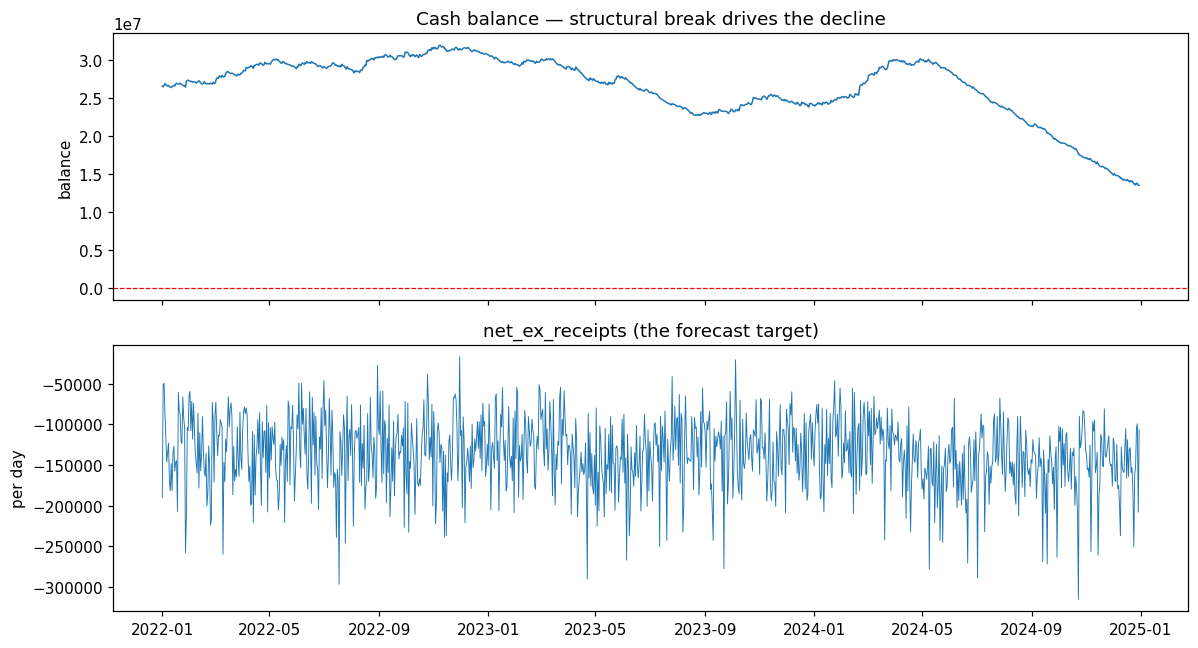

In [3]:
fig, ax = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
ax[0].plot(d.date, d.balance, lw=1)
ax[0].axhline(0, color='r', ls='--', lw=0.8)
ax[0].set_title('Cash balance — structural break drives the decline'); ax[0].set_ylabel('balance')
ax[1].plot(d.date, d.net_ex_receipts, lw=0.6)
ax[1].set_title('net_ex_receipts (the forecast target)'); ax[1].set_ylabel('per day')
plt.tight_layout(); plt.show()

## 2. Walk-forward (rolling-origin) selection

The origin advances by one horizon each fold. Every fold trains only on data strictly before its own test window, so no fold ever sees its own future.

In [4]:
from app.services.quant_core.forecasting import (
    walk_forward_validate, SeasonalNaiveForecaster, HoltWintersForecaster,
    SarimaxForecaster, select_and_forecast)

y = d['net_ex_receipts'].to_numpy()
factories = {'seasonal_naive': SeasonalNaiveForecaster,
             'holt_winters': HoltWintersForecaster,
             'sarimax': SarimaxForecaster}
rows = []
for name, f in factories.items():
    r = walk_forward_validate(y, f, horizon=14, n_folds=6)
    rows.append({'model': name, 'wf_RMSE': r.mean_rmse, 'wf_MAPE_%': r.mean_mape,
                 'AIC': r.aic, 'folds': len(r.fold_rmses),
                 'worst_fold_RMSE': max(r.fold_rmses)})
res = pd.DataFrame(rows).sort_values('wf_RMSE')
res

,model,wf_RMSE,wf_MAPE_%,AIC,folds,worst_fold_RMSE
1,holt_winters,44471.661871,29.214100,13271.346713,6,53208.478716
2,sarimax,46082.953335,32.542070,14812.126639,6,55830.515158
0,seasonal_naive,60623.138479,41.830502,NaN,6,81094.558278


### Why selection is on walk-forward RMSE, not AIC

Two independent reasons, and the second is the decisive one.

**1. AIC is not comparable across these three at all.** The seasonal naive baseline fits no likelihood, so it has no AIC. Ranking three models where one lacks the metric entirely compares incommensurable quantities.

**2. AIC and out-of-sample skill can disagree.** AIC is an *in-sample* criterion. On a different configuration of this same system (EASY regime, 730 days, 5 folds) the two criteria selected different models: SARIMAX won on walk-forward RMSE (39,417 vs 43,339) while having the **worse** AIC (9,778 vs 8,697). Walk-forward validation exists precisely to catch that case.

The cell below checks whether they agree *on this run*. They may well agree here — the point is not that AIC is always wrong, but that it cannot be relied on, and only the out-of-sample comparison tells you which situation you are in.

**MAPE is reported but never used to select.** `net_ex_receipts` crosses zero, so MAPE explodes near zero denominators; the percentages above are meaningless as a ranking.

In [5]:
best = res.iloc[0]['model']
print(f'selected: {best}')
aic_best = res.dropna(subset=['AIC']).sort_values('AIC').iloc[0]['model']
print(f'AIC would have selected: {aic_best}')
print('=> disagreement' if best != aic_best else '=> agreement')

selected: holt_winters
AIC would have selected: holt_winters
=> agreement


## 3. Per-fold spread

The mean hides the risk. A model with a good average and a terrible worst fold is a different proposition.

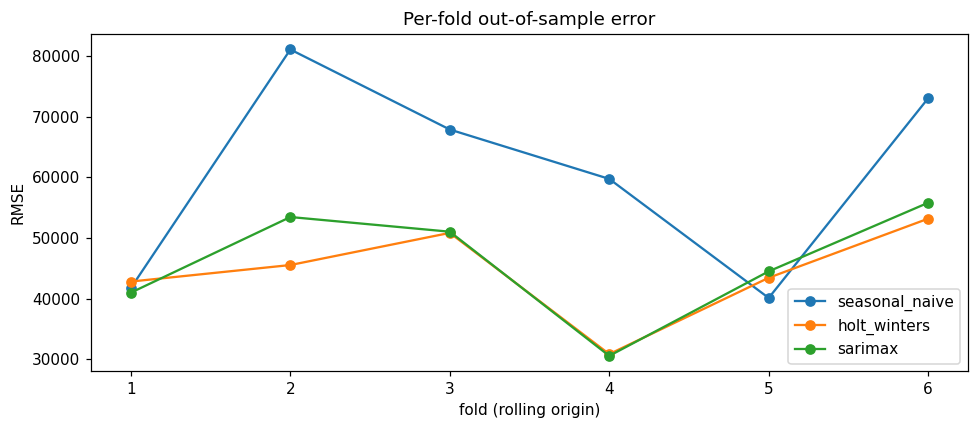

In [6]:
fig, ax = plt.subplots(figsize=(9,4))
for name, f in factories.items():
    r = walk_forward_validate(y, f, horizon=14, n_folds=6)
    ax.plot(range(1, len(r.fold_rmses)+1), r.fold_rmses, marker='o', label=name)
ax.set_xlabel('fold (rolling origin)'); ax.set_ylabel('RMSE')
ax.set_title('Per-fold out-of-sample error'); ax.legend(); plt.tight_layout(); plt.show()

## 4. The chosen model's forecast, with intervals

selected : holt_winters
rationale: holt_winters selected on lowest mean walk-forward RMSE (42,724) across 5 rolling-origin folds. holt_winters=42,724; sarimax=44,133; seasonal_naive=58,138. Selection is out-of-sample RMSE, not AIC, because the seasonal naive baseline defines no likelihood and cannot be ranked on AIC. ...
days_to_zero (POINT estimate): 88


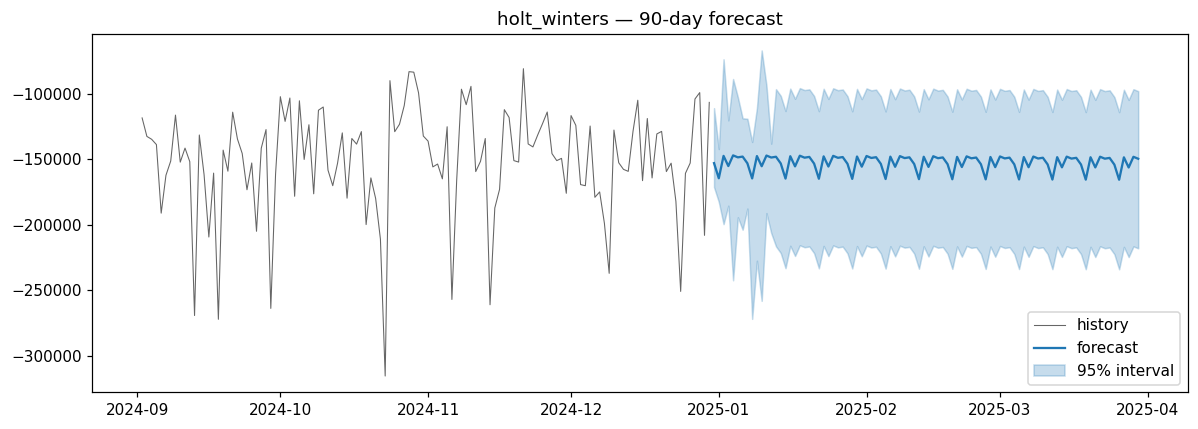

In [7]:
fc = select_and_forecast(d, horizon_days=90, value_column='net_ex_receipts',
                         opening_balance=float(d.balance.iloc[-1]))
print('selected :', fc.selected_model)
print('rationale:', fc.selection_rationale[:300], '...')
print('days_to_zero (POINT estimate):', fc.days_to_zero)

p = pd.DataFrame([{'d': x.as_of_date, 'point': x.point, 'lo': x.lower, 'hi': x.upper} for x in fc.path])
fig, ax = plt.subplots(figsize=(11,4))
ax.plot(d.date.tail(120), d.net_ex_receipts.tail(120), lw=0.7, color='0.4', label='history')
ax.plot(p.d, p.point, color='C0', label='forecast')
ax.fill_between(p.d, p.lo, p.hi, alpha=0.25, color='C0', label='95% interval')
ax.legend(); ax.set_title(f'{fc.selected_model} — 90-day forecast'); plt.tight_layout(); plt.show()

## 5. Limitation, stated plainly

The Section C backtest measures **~85% empirical coverage against a 95% nominal level**. These intervals are overconfident, which is the dangerous direction: A.2 turns interval width into the uncertainty behind Runway-at-Risk, so narrow intervals make RaR optimistic.

The most likely cause is the structural break — no extrapolative model anticipates a regime change, and intervals built from pre-break residuals understate post-break volatility. See `FORECASTING_METHODOLOGY.md` for the candidate fixes (GARCH-type variance, conformal prediction). None is implemented; the gap is reported rather than papered over.